In [60]:
import pandas as pd

In [61]:
data_jio = pd.read_csv('new_logs/jio-website-combined.log')
data_airtel = pd.read_csv('new_logs/airtel-webpage-loadtime.log')

In [62]:
# assign every unique url to a unique id
url_id = {}
id_url = {}

def get_url_id(url):
    if url not in url_id:
        url_id[url] = len(url_id)
        id_url[url_id[url]] = url
    return url_id[url]+1

data_jio['url_id'] = data_jio['url'].apply(get_url_id)
data_airtel['url_id'] = data_airtel['url'].apply(get_url_id)


In [63]:
data_jio

,url,size(bytes),time taken(s),speed(bytes/s),url_id
0,https://anantnag.nic.in,120505,4.460562,27015,1
1,https://anantnag.nic.in,120505,8.981729,13416,1
2,https://anantnag.nic.in,120497,8.529741,14126,1
3,https://anantnag.nic.in,120505,4.052053,29739,1
4,https://anantnag.nic.in,120497,5.124906,23512,1
...,...,...,...,...,...
191,https://udhampur.nic.in,118410,7.698665,15380,20
192,https://udhampur.nic.in,118410,11.331010,10450,20
193,https://udhampur.nic.in,118410,7.285988,16251,20
194,https://udhampur.nic.in,118410,3.281588,36083,20


In [64]:
data_airtel

,url,size(bytes),time taken(s),speed(bytes/s),url_id
0,https://anantnag.nic.in,120497,10.992881,10961,1
1,https://anantnag.nic.in,120497,16.418433,7339,1
2,https://anantnag.nic.in,120497,16.201545,7437,1
3,https://anantnag.nic.in,120497,16.381545,7355,1
4,https://anantnag.nic.in,120497,15.896645,7580,1
...,...,...,...,...,...
191,https://udhampur.nic.in,118410,15.630390,7575,20
192,https://udhampur.nic.in,118410,15.899253,7447,20
193,https://udhampur.nic.in,118410,15.878733,7457,20
194,https://udhampur.nic.in,118410,15.729954,7527,20


In [65]:
data_jio.columns, data_airtel.columns

(Index(['url', ' size(bytes)', ' time taken(s)', ' speed(bytes/s)', 'url_id'], dtype='object'),
 Index(['url', ' size(bytes)', ' time taken(s)', ' speed(bytes/s)', 'url_id'], dtype='object'))

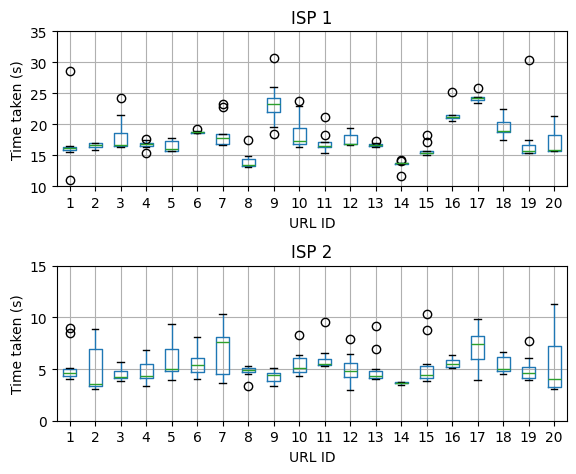

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

airtel = "ISP 1"
jio = "ISP 2"

fig, axs = plt.subplots(2, 1, figsize=(6, 5))



data_airtel.boxplot(column=' time taken(s)', by='url_id', ax=axs[0])
axs[0].set_title(airtel)
axs[0].set_ylabel('Time taken (s)')
axs[0].set_xlabel('URL ID')
# axs[0].set_yticks(range(0, 35, 5))
axs[0].set_ylim(10, 35)

data_jio.boxplot(column=' time taken(s)', by='url_id', ax=axs[1])
axs[1].set_title(jio)
axs[1].set_ylabel('Time taken (s)')
axs[1].set_xlabel('URL ID')
# axs[1].set_yticks(range(0, 35, 5))
axs[1].set_ylim(0, 15)

# set the font size to 16
# axs[0].tick_params(axis='both', which='major', labelsize=14)
# axs[1].tick_params(axis='both', which='major', labelsize=14)


plt.suptitle('')
plt.tight_layout(h_pad=1)
plt.show()
# set font size to 16


fig.savefig('webpage_loadtimes.pdf', bbox_inches='tight')


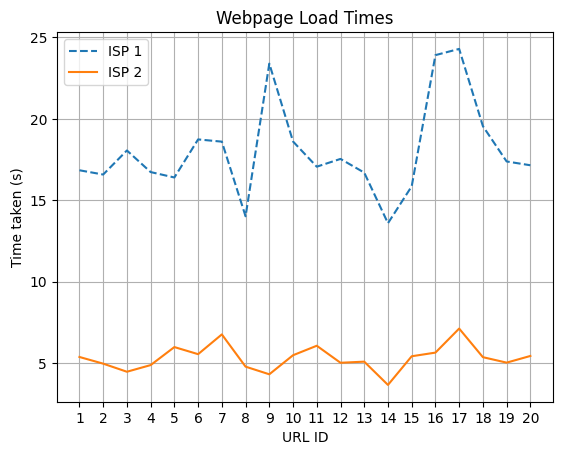

In [75]:
# group by url_id and get the mean time taken
data_airtel_grouped = data_airtel.groupby('url_id')[' time taken(s)'].mean().reset_index()
data_jio_grouped = data_jio.groupby('url_id')[' time taken(s)'].mean().reset_index()

plt.plot(data_airtel_grouped['url_id'], data_airtel_grouped[' time taken(s)'], label=airtel, linestyle='--')
plt.plot(data_jio_grouped['url_id'], data_jio_grouped[' time taken(s)'], label=jio)
plt.xticks(range(1, 21))
plt.title('Webpage Load Times')
plt.grid()
plt.xlabel('URL ID')
plt.ylabel('Time taken (s)')
plt.legend()